# Winner transfer and cross-slice context modeling

A reproducible review of the published aggregate evidence through **Stage 104**, as of **2026-10-06 03:25 UTC**. This notebook redraws charts from `reports/current_frontier/results.json`; it does not train a model or recompute private row-level scores.

**Read the settings separately:** the recorded external macro ROC-AUC is **0.943**. The following development chart uses a scanner-disjoint, weak-label research population of **4,349 studies**. These are different evaluation settings, and neither establishes clinical validity.

The public review is complete at this evidence boundary. Stage 105 is prepared privately and is not claimed complete. The published source now generates all four saved charts; the publication repair does not change any research metric.

## Grouped development progression
The gain from Stage 84 to Stage 102 is retained as development evidence. Stage 104 is a higher point estimate with an inconclusive incremental result; the truncated axis makes the small change visible.

Stage 102 gain: 0.0034614


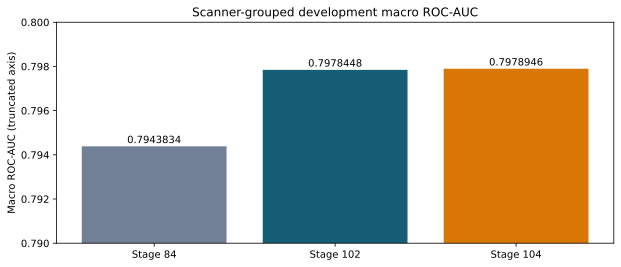

In [1]:
from pathlib import Path
import io
import json
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "reports/current_frontier/results.json").is_file())
sys.path.insert(0, str(ROOT / "src"))
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from rsna_review.evidence import summary

report = json.loads((ROOT / "reports/current_frontier/results.json").read_text())
evidence = summary(report)

def display_chart(fig, static):
    fig.update_layout(template="plotly_white", width=900, height=420, margin=dict(l=75, r=35, t=70, b=70), font=dict(size=14))
    buffer = io.StringIO()
    static.savefig(buffer, format="svg", bbox_inches="tight")
    plt.close(static)
    display({"application/vnd.plotly.v1+json": json.loads(fig.to_json()), "image/svg+xml": buffer.getvalue(), "text/plain": fig.layout.title.text}, raw=True)

labels = ["Stage 84", "Stage 102", "Stage 104"]
values = evidence["scores"]
fig = go.Figure(go.Bar(x=labels, y=values, marker_color=["#718096", "#155e75", "#d97706"]))
fig.update_layout(title="Scanner-grouped development macro ROC-AUC", yaxis_title="Macro ROC-AUC (truncated axis)", yaxis_range=[0.790, 0.800])
static, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color=["#718096", "#155e75", "#d97706"])
ax.set(ylim=(.790, .800), ylabel="Macro ROC-AUC (truncated axis)", title="Scanner-grouped development macro ROC-AUC")
for i, value in enumerate(values):
    ax.text(i, value + .00015, f"{value:.7f}", ha="center")
display_chart(fig, static)
print("Stage 102 gain:", f"{evidence['stage102_gain']:.7f}")

## Winner-technique coverage
The inventory spans 9 competitions, 15 solution lineages and 37 technique families. The chart below is the **29-mechanism high-confidence transfer checklist**, a subset of that inventory. Counts describe implementation coverage, not reproduced winning performance. Source attribution is documented in [the winner-transfer frontier](../docs/WINNER_TRANSFER_FRONTIER.md) and [research sources](../docs/SOURCES.md).

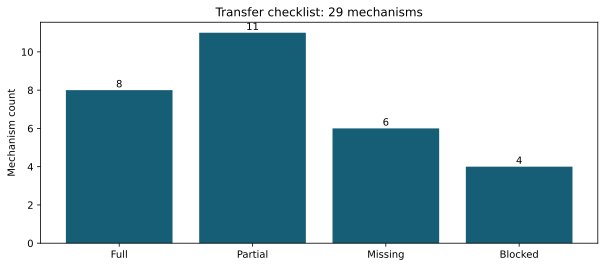

In [2]:
labels = ["Full", "Partial", "Missing", "Blocked"]
values = evidence["coverage"]
fig = go.Figure(go.Bar(x=labels, y=values, marker_color="#155e75"))
fig.update_layout(title="Transfer checklist: 29 mechanisms", yaxis_title="Mechanism count")
static, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color="#155e75")
ax.set(ylabel="Mechanism count", title="Transfer checklist: 29 mechanisms")
for i, value in enumerate(values):
    ax.text(i, value + .15, str(value), ha="center")
display_chart(fig, static)

## Validation population
The published fold counts sum to 4,349 development studies, with **59 scanner groups and zero cross-fold scanner overlap**. This is a count consistency check, not an independent reconstruction of private split membership. The 58 fully labeled audit rows have historical selection exposure; they are not an untouched confirmation cohort.

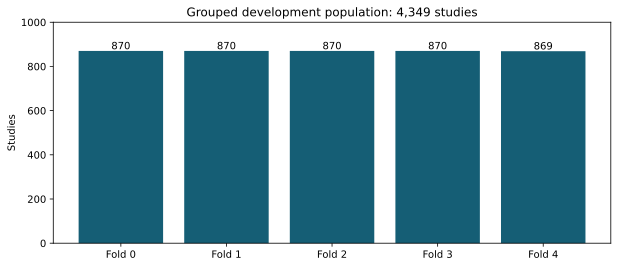

In [3]:
labels = ["Fold 0", "Fold 1", "Fold 2", "Fold 3", "Fold 4"]
values = evidence["folds"]
fig = go.Figure(go.Bar(x=labels, y=values, marker_color="#155e75"))
fig.update_layout(title="Grouped development population: 4,349 studies", yaxis_title="Studies")
static, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color="#155e75")
ax.set(ylabel="Studies", title="Grouped development population: 4,349 studies")
for i, value in enumerate(values):
    ax.text(i, value + 8, str(value), ha="center")
ax.set_ylim(0, 1000)
display_chart(fig, static)

## Stage 104 promotion decision
The notebook keeps both comparisons explicit. The increment over the Stage 102 reference is about **0.0000499**; the increment over the Stage 104 matched control is about **0.0000150**. The published Stage 104 90% interval crosses zero. The chart pairs the matched-control increment with that interval and keeps the outcome **inconclusive**. It does not recompute uncertainty from private predictions.

REVIEW_SUMMARY {"as_of_utc": "2026-10-06T03:25:00Z", "ci90": [-0.0001735904, 0.0002000818], "coverage": [8, 11, 6, 4], "folds": [870, 870, 870, 870, 869], "matched_delta": 1.495373571402947e-05, "scores": [0.7943833865949643, 0.7978447501637148, 0.7978946262164966], "stage102_gain": 0.0034613635687504862, "stage104_decision": "INCONCLUSIVE"}
M14_PUBLICATION_COMPLETE


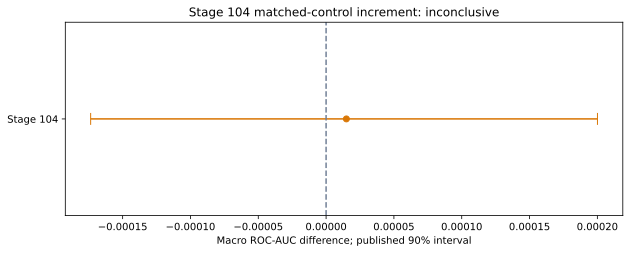

In [4]:
delta = evidence["matched_delta"]
lower, upper = evidence["ci90"]
fig = go.Figure(go.Scatter(x=[delta], y=["Stage 104"], mode="markers", marker=dict(size=12, color="#d97706"), error_x=dict(type="data", symmetric=False, array=[upper-delta], arrayminus=[delta-lower])))
fig.add_vline(x=0, line_dash="dash", line_color="#718096")
fig.update_layout(title="Stage 104 matched-control increment: inconclusive", xaxis_title="Macro ROC-AUC difference; published 90% interval", xaxis_tickformat=".5f")
static, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar([delta], [0], xerr=[[delta-lower], [upper-delta]], fmt="o", color="#d97706", capsize=6)
ax.axvline(0, color="#718096", linestyle="--")
ax.set(yticks=[0], yticklabels=["Stage 104"], xlabel="Macro ROC-AUC difference; published 90% interval", title="Stage 104 matched-control increment: inconclusive")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
display_chart(fig, static)
print("REVIEW_SUMMARY " + json.dumps(evidence, sort_keys=True))
print("M14_PUBLICATION_COMPLETE")

## What can be reproduced
Install the pinned public review requirements, run the synthetic twelve-label metric example, then execute this notebook with the documented save/reopen verifier. See [Reproducibility](../docs/REPRODUCIBILITY.md).

**Public:** aggregate evidence, original public helpers, validation fixtures, source attribution, review charts and CI. **Private:** MRI/DICOM, identifiers, predictions, weights, research runners, cloud locations and exact competition inference. These charts regenerate published aggregates; the competitive pipeline remains private. No diagnostic or clinical use is claimed.